#0. Introduzione
Il presente notebook si concentra sul preprocessing di un dataset clinico utilizzato per la classificazione di disturbi cognitivi. L’obiettivo è preparare i dati per l’addestramento di modelli di machine learning in grado di distinguere tra quattro condizioni diagnostiche:
- Assenza di disturbo
- Disturbo lieve
- Disturbo depressivo
- Malattia di Alzheimer

#1. Caricamento e analisi del dataset
In questa sezione viene caricato il dataset principale e vengono eseguite le prime analisi esplorative. L'obiettivo è comprendere la struttura dei dati, identificare e gestire la presenza di eventuali dati mancanti.

In [ ]:
# Importazione librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install /kaggle/input/imblearn/imbalanced_learn-0.10.1-py3-none-any.whl

In [ ]:
# Caricamento del file
file_path = 'DATASET_2.xlsx'
df = pd.read_excel(file_path)

In [ ]:
# Visualizzazione delle prime 10 righe
df.head(10)

,ID,CAP,Scolarita,Eta,Sesso,MMSE_PG,MMSE_PC,MMSE_PE,MMSE_ESITO,CLOCKTEST_PG,...,FAB_ESITO,FLUENZAVERBFON_PG,FLUENZAVERBFON_PC,FLUENZAVERBFON_PE,FLUENZAVERBFON_ESITO,TESTMATRICIATTENTIVE_PG,TESTMATRICIATTENTIVE_PC,TESTMATRICIATTENTIVE_PE,TESTMATRICIATTENTIVE_ESITO,Patologia
0,Row0,84018,13.0,65.0,F,29.0,2849.0,238.0,NORMA,5.0,...,NaN,24.0,209.0,1.0,AI LIMITI INFERIORI DELLA NORMA,47.0,4575.0,3.0,NORMA,Malattia di Alzheimer
1,Row1,80059,8.0,70.0,M,27.0,282.0,238.0,NORMA,6.0,...,NaN,31.0,349.0,4.0,NORMA,NaN,NaN,NaN,NaN,Assenza di patologia
2,Row2,80059,12.0,70.0,F,27.0,2686.0,238.0,NORMA,NaN,...,NaN,24.0,279.0,3.0,NORMA,45.0,47.0,3.0,NORMA,Malattia di Alzheimer
3,Row3,80071,8.0,66.0,M,17.0,1753.0,238.0,DEFICIT,2.0,...,DEFICIT,4.0,72.0,0.0,DEFICIT,7.0,525.0,0.0,DEFICIT,Malattia di Alzheimer
4,Row4,80059,7.0,82.0,M,25.0,25.0,238.0,NORMA,1.0,...,DEFICIT,11.0,214.0,2.0,NORMA,37.0,4175.0,2.0,NORMA,Malattia di Alzheimer
5,Row5,80059,5.0,63.0,F,28.0,2927.0,238.0,NORMA,10.0,...,NORMA,41.0,483.0,4.0,NORMA,NaN,NaN,NaN,NaN,Assenza di patologia
6,Row7,80054,11.0,48.0,F,29.0,2789.0,238.0,NORMA,NaN,...,NORMA,26.0,271.0,3.0,NORMA,NaN,NaN,NaN,NaN,Malattia di Alzheimer
7,Row11,80053,17.0,66.0,F,26.0,2446.0,238.0,NORMA,10.0,...,NaN,49.0,418.0,4.0,NORMA,40.0,3475.0,1.0,AI LIMITI INFERIORI DELLA NORMA,Malattia di Alzheimer
8,Row12,80058,5.0,69.0,F,26.0,2727.0,238.0,NORMA,NaN,...,NORMA,28.0,359.0,4.0,NORMA,37.0,40.0,2.0,NORMA,Assenza di patologia
9,Row14,80058,8.0,49.0,F,27.0,2662.0,238.0,NORMA,8.0,...,NaN,21.0,221.0,2.0,NORMA,50.0,4375.0,2.0,NORMA,Assenza di patologia


In [ ]:
# Dimensione del dataset
print("Shape del dataset:", df.shape)

Shape del dataset: (511, 41)


In [ ]:
# Identificazione righe duplicate
duplicate_rows = df.duplicated()

# Conteggio righe duplicate
num_duplicates = duplicate_rows.sum()

print(f"Numero di righe duplicate: {num_duplicates}")

Numero di righe duplicate: 0


In [ ]:
# Tipi di dati presenti
print("\nTipi di dati:")
print(df.dtypes)


Tipi di dati:
ID                             object
CAP                             int64
Scolarita                     float64
Eta                           float64
Sesso                          object
MMSE_PG                       float64
MMSE_PC                       float64
MMSE_PE                       float64
MMSE_ESITO                     object
CLOCKTEST_PG                  float64
CLOCKTEST_PE                  float64
CLOCKTEST_ESITO                object
COPIAFIGURAREY_PG             float64
COPIAFIGURAREY_PC             float64
COPIAFIGURAREY_PE             float64
COPIAFIGURAREY_ESITO           object
PAROLEREYIMM_PG               float64
PAROLEREYIMM_PC               float64
PAROLEREYIMM_PE               float64
PAROLEREYIMM_ESITO             object
PAROLEREYDIFF_PG              float64
PAROLEREYDIFF_PC              float64
PAROLEREYDIFF_PE              float64
PAROLEREYDIFF_ESITO            object
MEMORIAFIGURAREY_PG           float64
MEMORIAFIGURAREY_PE           float

Il dataset include una serie di variabili raccolte da valutazioni neuropsicologiche e informazioni anagrafiche. Ogni riga rappresenta un soggetto, identificato tramite un codice (ID), e descritto da:

- Variabili demografiche: età (Eta), sesso (Sesso), scolarità (Scolarita), e codice postale (CAP);
- Risultati di test neuropsicologici, come:
  - MMSE (Mini Mental State Examination): Test generale per valutare lo stato cognitivo globale.
  - CLOCKTEST (Test dell’orologio): Valuta le abilità visuospaziali e la pianificazione (disegno di un orologio).
  - FAB (Frontal Assessment Battery): Testa le funzioni esecutive frontali (es. inibizione, flessibilità cognitiva).
  - PAROLEREYIMM: Valuta la memoria verbale immediata (richiamo di parole appena ascoltate).
  - PAROLEREYDIFF: Misura la memoria verbale differita (richiamo dopo un intervallo).
  - MEMORIAFIGURAREY (test visuospaziale): Valuta la memoria visiva a lungo termine (richiamo di una figura).
  - COPIAFIGURAREY (test visuospaziale): Misura la capacità di copiare una figura complessa (abilità visuocostruttive).
  - FLUENZAVERBFON: Misura la capacità di generare parole a partire da una lettera (fluenza fonemica).
  - TESTMATRICIATTENTIVE: Valuta l’attenzione e il ragionamento logico con stimoli visivi.

Ogni test è riportato con:
- punteggio grezzi (_PG): punteggio ottenuto direttamente dal test;
- punteggio percentile (_PC):  confronto con i punteggi della popolazione normale;
- punteggi equivalenti (_PE): punteggio standardizzato su scala clinica.
- giudizio qualitativo (_ESITO).

La variabile target, Patologia, indica la diagnosi clinica assegnata a ciascun soggetto.

In [ ]:
# Funzione che stampa il numero e la percentuale di valori mancanti per colonna in un DataFrame
# Parametri: dataframe
def report_missing_values(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    missing_table = pd.DataFrame({
      'Missing Values': missing,
      'Percentage (%)': percent.round(2)
    })
    print("\nValori mancanti per colonna:")
    print(missing_table)

In [ ]:
report_missing_values(df)


Valori mancanti per colonna:
                            Missing Values  Percentage (%)
ID                                       0            0.00
CAP                                      0            0.00
Scolarita                               16            3.13
Eta                                    137           26.81
Sesso                                  138           27.01
MMSE_PG                                  7            1.37
MMSE_PC                                126           24.66
MMSE_PE                                126           24.66
MMSE_ESITO                               8            1.57
CLOCKTEST_PG                           135           26.42
CLOCKTEST_PE                           142           27.79
CLOCKTEST_ESITO                         18            3.52
COPIAFIGURAREY_PG                       88           17.22
COPIAFIGURAREY_PC                      121           23.68
COPIAFIGURAREY_PE                       63           12.33
COPIAFIGURAREY_ESITO      

E' stato osservato che la quasi totalità delle colonne del dataset (escluse le colonne identificative ID e CAP) presenta valori mancanti, in alcuni casi con percentuali molto elevate.

In una prima fase si è proceduto eliminando:
- le istanze senza target, poiché inutilizzabili ai fini della modellazione supervisionata;
- le colonne con più del 50% di valori mancanti (relative al test FAB), in quanto mantenere colonne con pochi dati può introdurre rumore e ridurre l'efficacia dei modelli predittivi;
- le righe con più del 50% di valori mancanti, per evitare che la scarsità di informazioni compromettesse l’affidabilità del modello.

In [ ]:
# Drop dei record con target mancante
df = df.dropna(subset=['Patologia'])
print("Shape del dataset dopo l'eliminazione delle istanze senza 'Patologia':", df.shape)

Shape del dataset dopo l'eliminazione delle istanze senza 'Patologia': (495, 41)


In [ ]:
# Eliminazione colonne con più del 50% di valori mancanti
threshold = 0.5  # soglia del 50%
df = df.loc[:, df.isnull().mean() < threshold]

# Eliminazione delle righe con più del 50% di valori mancanti
df = df[df.isnull().mean(axis=1) < threshold]

# Dimensione dataset dopo l'eliminazione di righe e colonne con 50% di valori mancanti
print("Shape del dataset dopo l'eliminazione di righe e colonne con 50% di valori mancanti:", df.shape)

Shape del dataset dopo l'eliminazione di righe e colonne con 50% di valori mancanti: (479, 37)


Le colonne relative ai punteggi grezzi "_PG" e agli esiti "_ESITO" sono quelle che presentano meno missing values rispetto alle rispettive colonne "_PC" e "_PE".

Al fine di individuare eventuali outliers, sono state esplorate le colonne "_PG".

In [ ]:
# Controllo range numerico colonne _PG
for col in df.columns:
    if col.endswith("_PG"):
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")

MMSE_PG: min=10.0, max=30.0
CLOCKTEST_PG: min=0.0, max=10.0
COPIAFIGURAREY_PG: min=0.0, max=44.0
PAROLEREYIMM_PG: min=2.0, max=60.0
PAROLEREYDIFF_PG: min=0.0, max=12.0
MEMORIAFIGURAREY_PG: min=0.0, max=30.0
FLUENZAVERBFON_PG: min=2.0, max=64.0
TESTMATRICIATTENTIVE_PG: min=0.0, max=552.0


Analizzando i range dei punteggi grezzi (PG) dei test, si osserva che i punteggi di tutti i test risultano coerenti con quanto atteso dalla letteratura clinica, ad eccezione di due variabili: 'FLUENZAVERBFON_PG' e 'TESTMATRICIATTENTIVE_PG'.

Per il test sulla Fluenza fonemica, il range atteso è 0-60. Il valore massimo osservato è 64, il quale è improbabile e non compatibile con le norme standard. Si procede pertanto con la sostituzione del valore improprio con un NaN.

Per il test delle Matrici attentive, il range atteso è 0-50/60 a seconda della versione del test utilizzata. Nel dataset è stato osservato un valore massimo di 552,  chiaramente anomalo e clinicamente implausibile. Non avendo informazioni circa la versione di test utilizzata, anche in questo caso si procede con la sostituzione del punteggio improprio >60 con un NaN.




In [ ]:
# Funzione che stampa e righe dove il valore di col_pg supera max_value, mostrando anche le relative colonne PC, PE ed ESITO.
def check_outliers_PG(df, col_pg, max_value):

    if col_pg not in df.columns:
        print(f"Colonna '{col_pg}' non trovata.")
        return

    base_name = col_pg.replace('_PG', '')

    related_cols = [
        col_pg,
        f"{base_name}_PC",
        f"{base_name}_PE",
        f"{base_name}_ESITO"
    ]

    # Filtra e stampa
    outliers = df[df[col_pg] > max_value][related_cols]

    if outliers.empty:
        print(f"Nessun valore superiore a {max_value} in {col_pg}")
    else:
        print(f"Valori oltre {max_value} in {col_pg} (con PC, PE, ESITO):")
        display(outliers)

In [ ]:
# Test colonna FLUENZAVERBFON_PG
check_outliers_PG(df, 'FLUENZAVERBFON_PG', 50)

Valori oltre 50 in FLUENZAVERBFON_PG (con PC, PE, ESITO):


,FLUENZAVERBFON_PG,FLUENZAVERBFON_PC,FLUENZAVERBFON_PE,FLUENZAVERBFON_ESITO
39,53.0,545.0,4.0,NORMA
92,56.0,4.0,NaN,NORMA
127,52.0,455.0,4.0,NORMA
183,64.0,562.0,4.0,NORMA
193,52.0,436.0,4.0,NORMA
203,55.0,466.0,4.0,NORMA
262,52.0,483.0,4.0,NORMA
369,55.0,582.0,4.0,NORMA
380,51.0,438.0,4.0,NORMA


In [ ]:
# Per il TEST FUENZA VERBALE FONEMICA i valori fuori dal range [0,60] sono fuori scala -> vengono sostituiti con NaN
df.loc[df["FLUENZAVERBFON_PG"] > 60, "FLUENZAVERBFON_PG"] = None

In [ ]:
# Test colonna TESTMATRICIATTENTIVE_PG
check_outliers_PG(df, 'TESTMATRICIATTENTIVE_PG', 60)

Valori oltre 60 in TESTMATRICIATTENTIVE_PG (con PC, PE, ESITO):


,TESTMATRICIATTENTIVE_PG,TESTMATRICIATTENTIVE_PC,TESTMATRICIATTENTIVE_PE,TESTMATRICIATTENTIVE_ESITO
177,119.0,NaN,0.0,DEFICIT
251,552.0,54975.0,4.0,NORMA


In [ ]:
# Per il TEST MATRICI ATTENTIVE i valori fuori dal range [0,60] sono fuori scala -> vengono sostituiti con NaN
df.loc[df["TESTMATRICIATTENTIVE_PG"] > 60, "TESTMATRICIATTENTIVE_PG"] = None

In [ ]:
report_missing_values(df)


Valori mancanti per colonna:
                            Missing Values  Percentage (%)
ID                                       0            0.00
CAP                                      0            0.00
Scolarita                                8            1.67
Eta                                    133           27.77
Sesso                                  133           27.77
MMSE_PG                                  1            0.21
MMSE_PC                                114           23.80
MMSE_PE                                113           23.59
MMSE_ESITO                               0            0.00
CLOCKTEST_PG                           118           24.63
CLOCKTEST_PE                           125           26.10
CLOCKTEST_ESITO                          3            0.63
COPIAFIGURAREY_PG                       70           14.61
COPIAFIGURAREY_PC                      102           21.29
COPIAFIGURAREY_PE                       43            8.98
COPIAFIGURAREY_ESITO      

Da un'attenta osservazione delle colonne che terminano in '_PC' (punteggi percentili) e '_PE' (punteggi equivalenti) è emerso che questi campi contengono numerosi valori corrotti o difficili da interpretare. La loro gestione risulta complessa in quanto richiederebbe informazioni aggiuntive (es. norme di riferimento per età e scolarità) che non sono disponibili.

Inoltre, queste colonne presentano una percentuale di valori mancanti significativamente superiore rispetto ai corrispondenti punteggi grezzi ('_PG'), da cui i PE e i PC sono calcolati. I punteggi grezzi risultano quindi più affidabili e informativi ai fini dell’analisi.

Per questi motivi, e al fine di migliorare la qualità e la coerenza del dataset, si è deciso di **eliminare tutte le colonne con suffisso '_PE' e '_PC'**, mantenendo invece i punteggi grezzi ('_PG') e tutte le altre variabili rilevanti.


In [ ]:
# Le colonne che terminano con *_PC e *_PE sono molto danneggiate -> eliminazione

# Selezione delle colonne che finiscono con _PC o _PE
cols_to_drop = [col for col in df.columns if col.endswith('_PC') or col.endswith('_PE')]

# Eliminazione colonne dal dataframe
df = df.drop(columns=cols_to_drop)

Sono stanche eliminate anche le colonne "ID" e "CAP" perchè non contengono informazioni utili all'analisi e introducono bias.

In [ ]:
# Eliminazione delle colonne ID e CAP

df = df.drop(columns=['ID', 'CAP'])

In [ ]:
print('Le colonne del dataframe aggiornato sono', len(df.columns),':', list(df.columns))


Le colonne del dataframe aggiornato sono 20 : ['Scolarita', 'Eta', 'Sesso', 'MMSE_PG', 'MMSE_ESITO', 'CLOCKTEST_PG', 'CLOCKTEST_ESITO', 'COPIAFIGURAREY_PG', 'COPIAFIGURAREY_ESITO', 'PAROLEREYIMM_PG', 'PAROLEREYIMM_ESITO', 'PAROLEREYDIFF_PG', 'PAROLEREYDIFF_ESITO', 'MEMORIAFIGURAREY_PG', 'MEMORIAFIGURAREY_ESITO', 'FLUENZAVERBFON_PG', 'FLUENZAVERBFON_ESITO', 'TESTMATRICIATTENTIVE_PG', 'TESTMATRICIATTENTIVE_ESITO', 'Patologia']


Successivamente, sono state esplorate e pulite le variabili categoriche 'sesso' e '_ESITO'.

In [ ]:
# Visualizzazione categorie colonne *_ESITO

# Seleziona solo le colonne che finiscono con "_ESITO"
esito_cols = [col for col in df.columns if col.endswith('_ESITO')]

# Visualizza i valori unici per ciascuna colonna _ESITO
for col in esito_cols:
    print(f"\nValori unici per '{col}':")
    print(df[col].unique())


Valori unici per 'MMSE_ESITO':
['NORMA' 'DEFICIT' 'LIMITI']

Valori unici per 'CLOCKTEST_ESITO':
['DEFICIT' 'NORMA' 'LIMITI' nan]

Valori unici per 'COPIAFIGURAREY_ESITO':
['NORMA' 'DEFICIT' 'AI LIMITI INFERIORI DELLA NORMA' nan]

Valori unici per 'PAROLEREYIMM_ESITO':
['DEFICIT' 'NORMA' 'AI LIMITI INFERIORI DELLA NORMA' nan]

Valori unici per 'PAROLEREYDIFF_ESITO':
['NORMA' 'DEFICIT' 'AI LIMITI INFERIORI DELLA NORMA' nan]

Valori unici per 'MEMORIAFIGURAREY_ESITO':
['DEFICIT' 'AI LIMITI INFERIORI DELLA NORMA' 'NORMA' nan]

Valori unici per 'FLUENZAVERBFON_ESITO':
['AI LIMITI INFERIORI DELLA NORMA' 'NORMA' 'DEFICIT' nan]

Valori unici per 'TESTMATRICIATTENTIVE_ESITO':
['NORMA' nan 'DEFICIT' 'AI LIMITI INFERIORI DELLA NORMA']


In [ ]:
# Sostituzione di 'LIMITI' e 'AI LIMITI INFERIORI DELLA NORMA' con 'BORDERLINE'

sostituzioni = {
    'LIMITI': 'BORDERLINE',
    'AI LIMITI INFERIORI DELLA NORMA': 'BORDERLINE'
}

df[esito_cols] = df[esito_cols].replace(sostituzioni)

In [ ]:
# Visualizzazione categorie della variabile 'Sesso'
df['Sesso'].unique()

array(['F', 'M', nan, 'f', 'm'], dtype=object)

In [ ]:
# Pulizia valori colonna Sesso
df['Sesso'] = df['Sesso'].str.strip().str.upper()
df['Sesso'].unique()

array(['F', 'M', nan], dtype=object)

## Analisi delle distribuzioni delle variabili

Di seguito è riportata la matrice di correlazione tra le variabili 'età', 'scolarità' e i punteggi grezzi ('*_PG'), che evidenzia un elevato livello di correlazione tra alcune di esse.

Nonostante ciò, in un primo esperimento, tutte le variabili sono state mantenute nella fase di modellazione per diversi motivi:
- In fase esplorativa, l'obiettivo era identificare i **modelli migliori in termini predittivi**, anche a costo di includere feature correlate.
- Alcuni algoritmi (es. albero decisionale, random forest) sono **robusti alla multicollinearità** e in grado di selezionare automaticamente le feature più rilevanti.
- La presenza di correlazioni non implica necessariamente **ridondanza informativa completa**: alcune variabili possono comunque contribuire a migliorare la performance del modello.


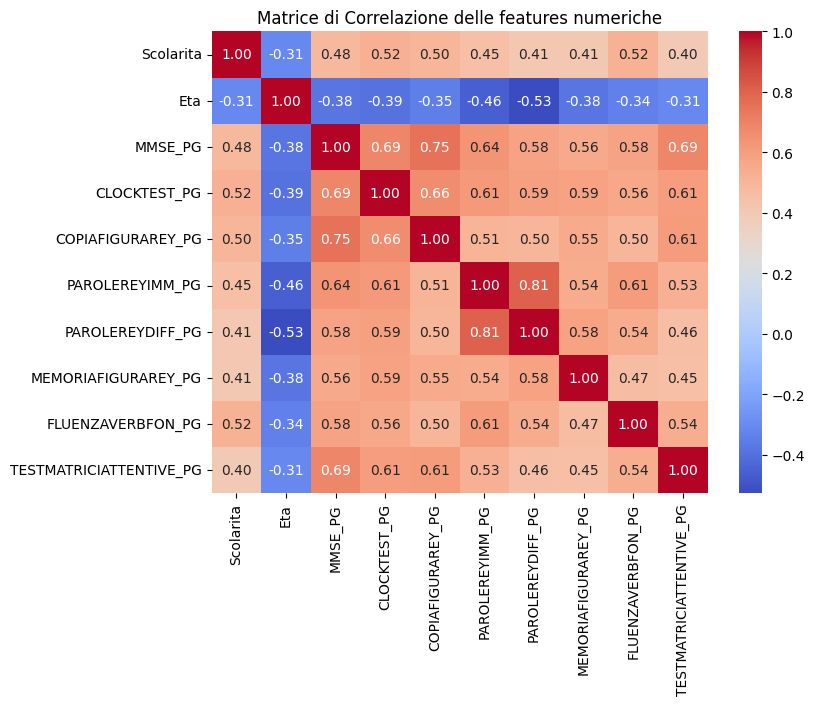

In [ ]:
# Verifica correlazione tra colone 'ETA', 'SCOLARITA' E '*_PG*

# Filtra le colonne categoriche: esclude 'Sesso, 'Patologia' e tutte quelle che terminano con '_ESITO'
colonne_filtrate = [col for col in df.columns if col not in ['Patologia', 'Sesso'] and not col.endswith('_ESITO')]

# Crea un nuovo DataFrame solo con le colonne filtrate
df_corr = df[colonne_filtrate]

# Calcola la matrice di correlazione
correlation_matrix = df_corr.corr()

# Visualizza la matrice
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice di Correlazione delle features numeriche')
plt.show()


Il seguente istogramma riporta la distribuzione della variabile 'Eta' che risulta essere spostata verso destra. In seguito i missing values verrano imputati utilizzando la mediana.

Media di Età: 66.29
Mediana di Età: 68.00


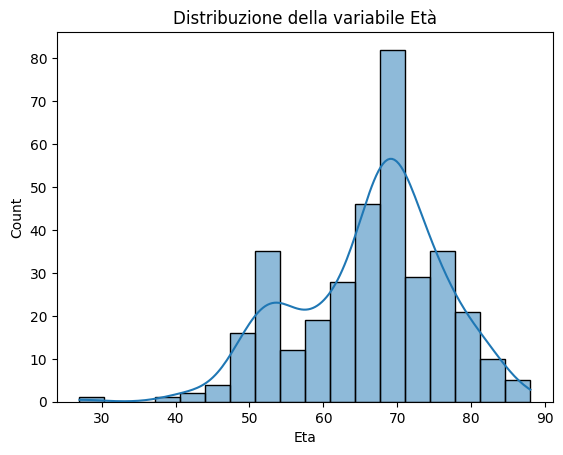

In [ ]:
mean_val = df['Eta'].mean()
median_val = df['Eta'].median()

print(f"Media di Età: {mean_val:.2f}")
print(f"Mediana di Età: {median_val:.2f}")

sns.histplot(df['Eta'], kde=True)
plt.title("Distribuzione della variabile Età")
plt.show()


Il presente istogramma riporta la distribuzione della variabile Scolarità, la quale risulta non essere né uniforme né simmetrica. Questo suggerisce che la tecnica di imputazione più appropriata per i dati mancanti sia l'utilizzo della mediana.

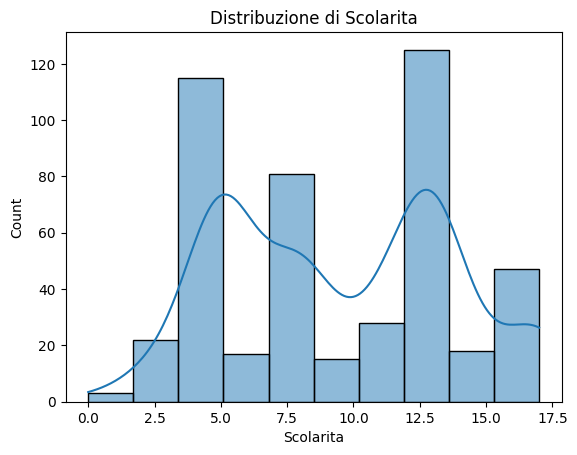

Media: 9.501061571125266
Mediana: 8.0


In [ ]:
# Distribuzione di Scolarita
sns.histplot(df['Scolarita'], kde=True)
plt.title("Distribuzione di Scolarita")
plt.show()

print("Media:", df['Scolarita'].mean())
print("Mediana:", df['Scolarita'].median())

Dalla distribuzione della variabile Sesso emerge una marcata predominanza della categoria 'Femminile' rispetto a quella 'Maschile'. I dati mancanti saranno imputati con la moda.

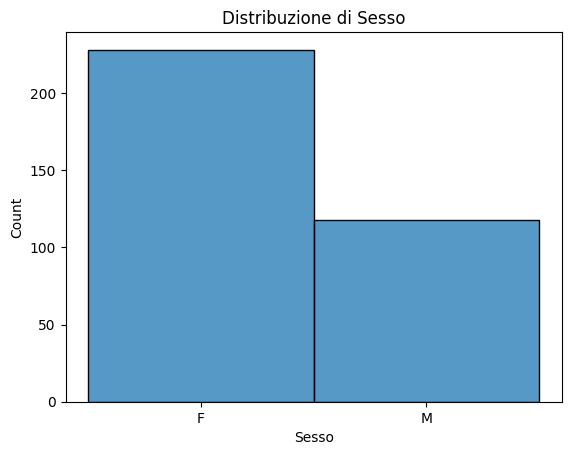

Moda: F


In [ ]:
# Distribuzione di Sesso
sns.histplot(df['Sesso'])
plt.title("Distribuzione di Sesso")
plt.show()

print("Moda:", df['Sesso'].mode()[0])

Sono stati generati i violin plot per tutte le colonne "_PG" rispetto alle corrispondenti "_ESITO". Si osserva che molte distribuzioni sono molto allungate verticalmente, segnalando una forte variabilità dei punteggi e la presenza di possibili outlier.

Questo suggerisce che il metodo più appropriato per imputare i valori mancanti è la mediana, in quanto meno influenzata dagli outlier e più rappresentativa del valore centrale della distribuzione.

Durante la modellazione, per ogni categoria nella colonna "_ESITO" verrà calcolata la mediana dei valori corrispondenti nella colonna "_PG", che sarà utilizzata per imputare i dati mancanti nelle colonne "_PG" associate a quella categoria di "_ESITO". In questo modo, l’imputazione rispetta la relazione tra punteggi e gruppi di esito.


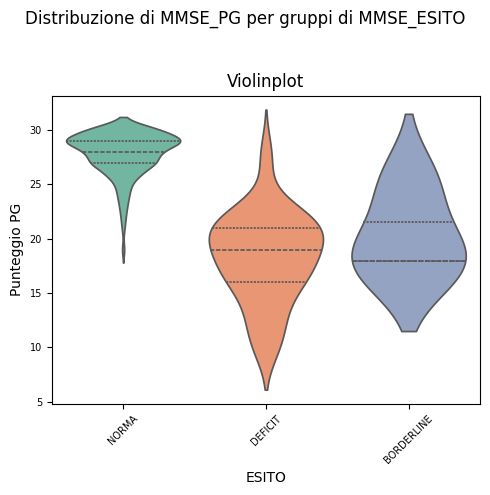

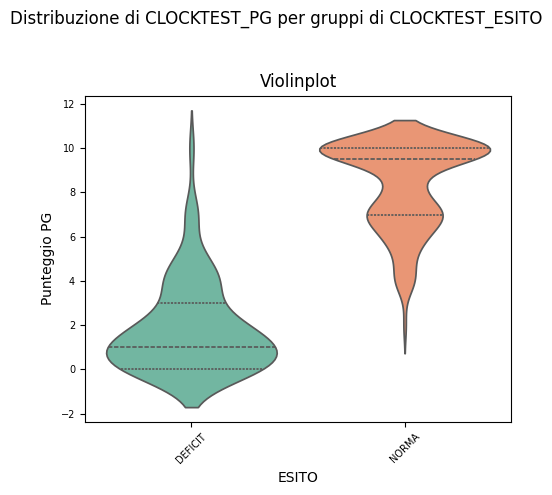

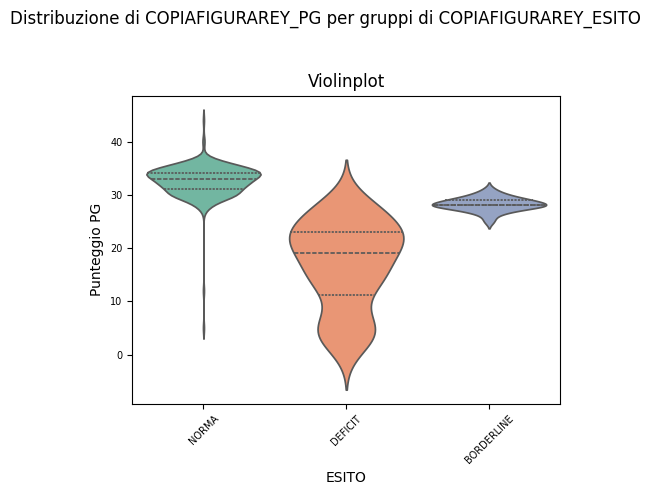

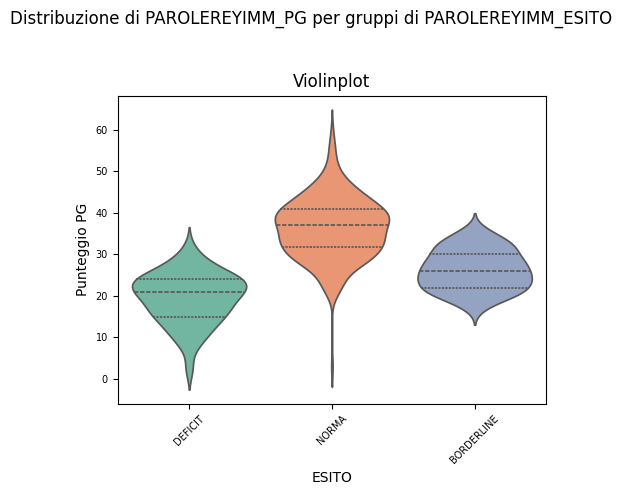

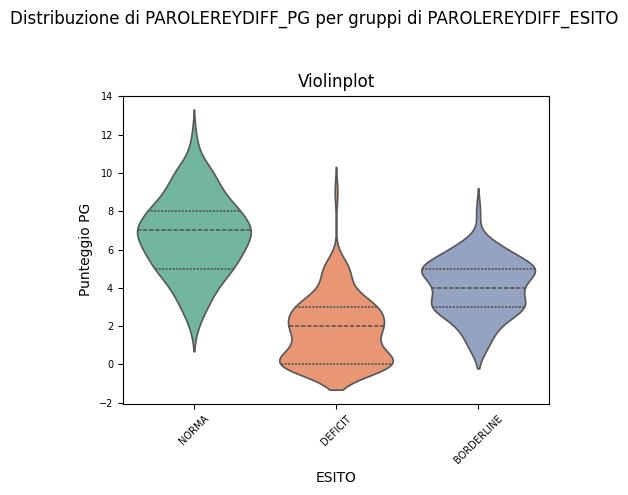

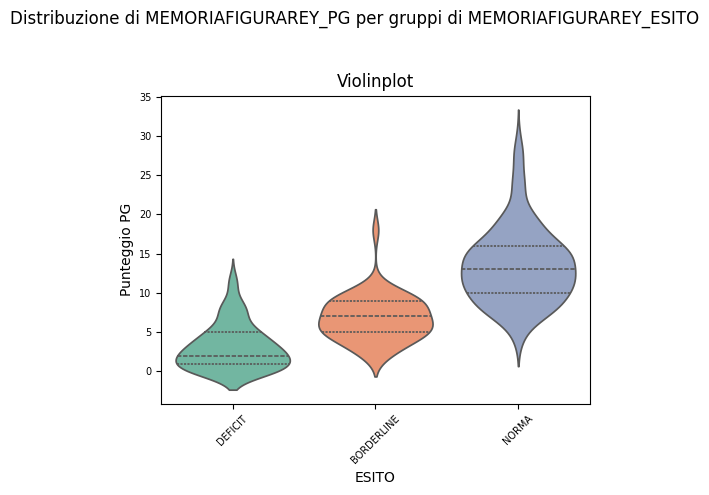

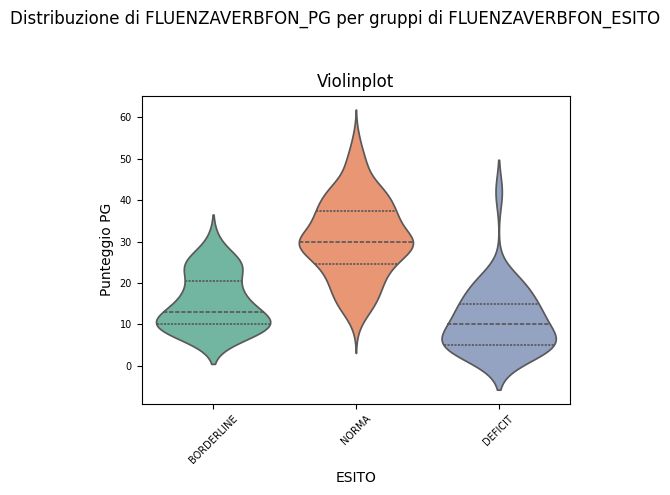

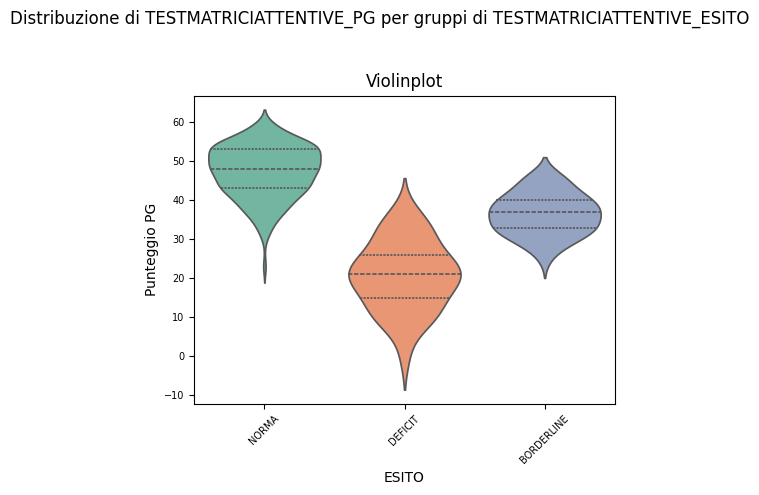

In [ ]:
# Trova tutte le colonne che terminano con '_PG'
pg_cols = [col for col in df.columns if col.endswith('_PG')]

for pg_col in pg_cols:
    prefix = pg_col[:-3]  # rimuove '_PG'
    esito_col = f"{prefix}_ESITO"

    if esito_col in df.columns:
        # Filtra solo righe senza NaN in entrambe le colonne
        df_sub = df[[pg_col, esito_col]].dropna()

        if df_sub.empty:
            print(f"Nessun dato valido per {pg_col} e {esito_col}")
            continue

        plt.figure(figsize=(5,5))
        plt.suptitle(f'Distribuzione di {pg_col} per gruppi di {esito_col}', fontsize=12)

        # Violinplot
        sns.violinplot(
            x=esito_col,
            y=pg_col,
            data=df_sub,
            hue=esito_col,
            palette='Set2',
            inner='quartile',
            legend=False
        )
        plt.xticks(rotation=45)
        plt.title('Violinplot')
        plt.xlabel('ESITO')
        plt.ylabel('Punteggio PG')
        plt.xticks(fontsize=7)
        plt.yticks(fontsize=7)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        print("\n")
    else:
        print(f"Colonna {esito_col} mancante per {pg_col}")


# 2. Distribuzione variabile target e salvataggio dataset
L'obiettivo di questa sezione è preparare diverse versioni del dataset, ciascuna costruita con un diverso schema di classificazione del target (Patologia).
I dataset risultanti vengono salvati e successivamente utilizzati in altri notebook dedicati all’addestramento dei modelli.


###Distribuzione originale delle classi

In [ ]:
# Funzione che stampa un grafico a torta in cui è possibile visualizzare la percentuale di ciascuna classe target presente nel dataset
def plot_pie_chart(series, title, colors):
    labels = series.index.tolist()
    wg = {'linewidth': 0.7, 'edgecolor': 'black'}

    plt.figure(figsize=(6, 6))
    patches, texts, autotexts = plt.pie(
        series,
        explode=[0]*len(series),
        colors=colors,
        autopct='%1.1f%%',
        startangle=-90,
        wedgeprops=wg
    )

    plt.setp(autotexts, fontsize=19, color='white', fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    legend_text = [f"{label}: {count}" for label, count in zip(labels, series)]
    plt.legend(legend_text)
    plt.tight_layout()
    plt.show()


La distribuzione delle classi nella variabile target Patologia risulta fortemente sbilanciata, con una netta predominanza della classe "Assenza di patologia" rispetto alle altre.

Il dataset pre-elaborato è stato salvato come:
df_4_pg_esito.csv

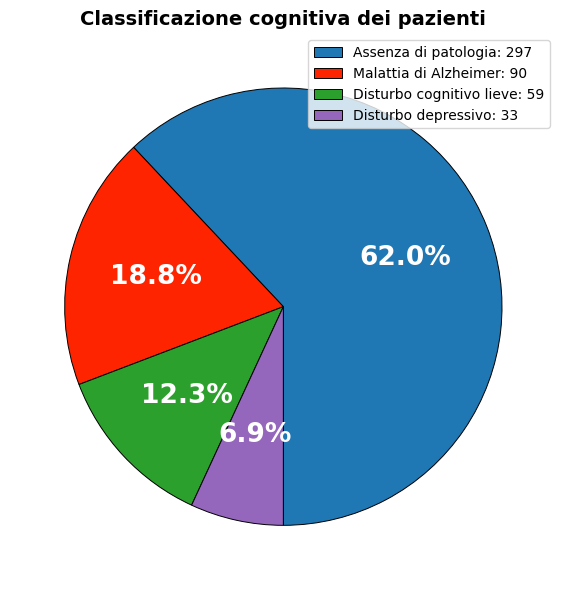

In [ ]:
# Dataset originale
nlabel = df['Patologia'].value_counts()
plot_pie_chart(nlabel, 'Classificazione cognitiva dei pazienti', ['#1F77B4', '#FF2400', '#2CA02C', '#9467BD'])
# Salvataggio df processato
df.to_csv('df_4_pg_esito.csv', index=False)

###Prima riclassificazione: 3 classi
Prima riclassificazione: 3 classi

Poiché i modelli iniziali hanno ottenuto prestazioni non soddisfacenti, si è ipotizzato che la scarsa numerosità delle istanze appartenenti alle classi "Disturbo lieve" e "Disturbo depressivo" ne fosse una delle cause principali.

Per questo motivo, si è definita una nuova versione della variabile target con 3 classi:
- Assenza di patologia
- Disturbo non Alzheimer → unione di Disturbo lieve e Disturbo depressivo
- Malattia di Alzheimer

Anche in questo caso, la distribuzione delle classi risulta sbilanciata.

Il dataset è stato salvato come: df_3_pg_esito.csv

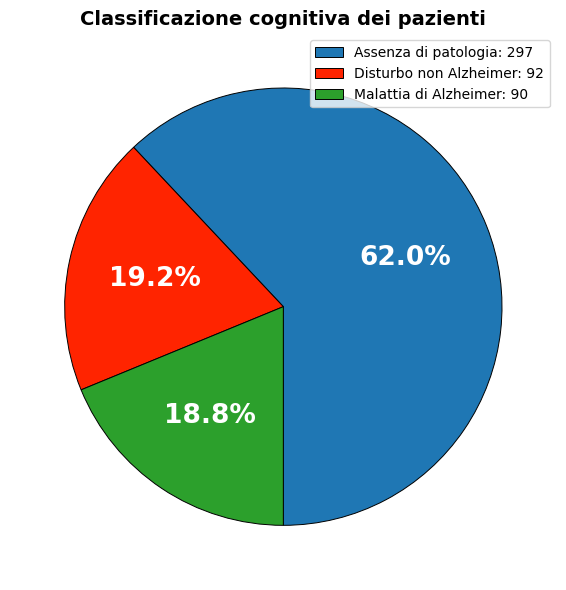

In [ ]:
# Prima unificazione: 'Disturbo non Alzheimer'
df_1 = df.copy()
df_1['Patologia'] = df_1['Patologia'].replace({
    'Disturbo cognitivo lieve': 'Disturbo non Alzheimer',
    'Disturbo depressivo': 'Disturbo non Alzheimer'
})

nlabel = df_1['Patologia'].value_counts()
plot_pie_chart(nlabel, 'Classificazione cognitiva dei pazienti', ['#1F77B4', '#FF2400', '#2CA02C'])
df_1.to_csv('df_3_pg_esito.csv', index=False)


### Seconda riclassificazione: classificazione binaria

Successivamente, è stata creata una versione binaria della variabile target, con l’obiettivo di discriminare tra assenza e presenza di una qualsiasi forma di disturbo cognitivo.

La variabile target è stata così riclassificata:
- Assenza di disturbo → include: Assenza di patologia
- Presenza di disturbo → unione di: Disturbo cognitivo lieve, Disturbo depressivo e Malattia di Alzheimer

Il dataset è stato salvato come: df_2_pg_esito.csv

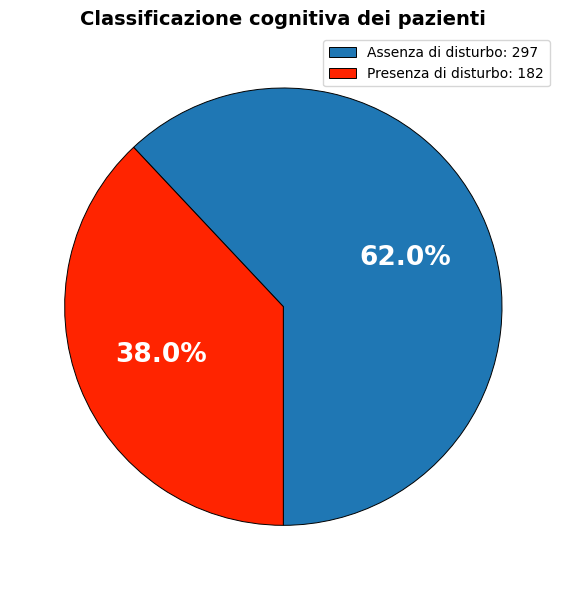

In [ ]:
# Seconda unificazione: 'Presenza vs Assenza di disturbo'
df_2 = df.copy()
df_2['Patologia'] = df_2['Patologia'].replace({
    'Disturbo cognitivo lieve': 'Presenza di disturbo',
    'Disturbo depressivo': 'Presenza di disturbo',
    'Malattia di Alzheimer': 'Presenza di disturbo',
    'Assenza di patologia': 'Assenza di disturbo'
})

nlabel = df_2['Patologia'].value_counts()
plot_pie_chart(nlabel, 'Classificazione cognitiva dei pazienti', ['#1F77B4', '#FF2400'])
df_2.to_csv('df_2_pg_esito.csv', index=False)

###Terza riclassificazione: solo le patologie

Infine, è stata condotta un’analisi limitata ai soli soggetti con patologia presente. Sono state quindi eliminate le istanze corrispondenti alla classe "Assenza di patologia" e il focus è stato posto sulla classificazione tra:
- Disturbo cognitivo lieve
- Disturbo depressivo
- Malattia di Alzheimer

Il dataset è stato salvato come: df_dist_pg_esito.csv

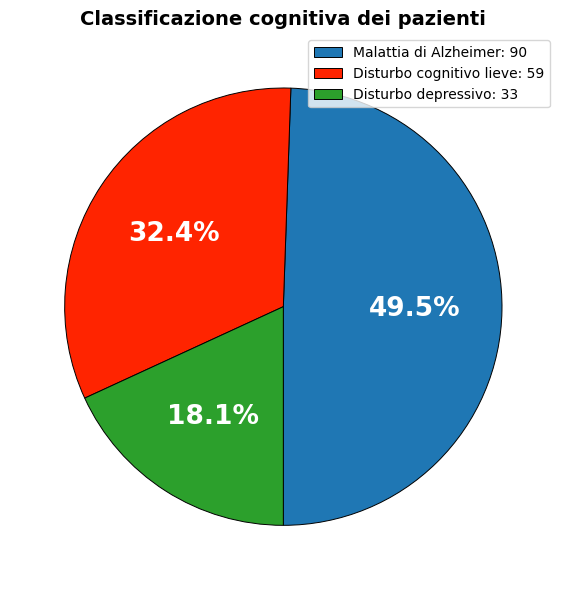

In [ ]:
# Terza trasformazione: solo pazienti con disturbo
df_3 = df[df['Patologia'] != 'Assenza di patologia'].copy()

nlabel = df_3['Patologia'].value_counts()
plot_pie_chart(nlabel, 'Classificazione cognitiva dei pazienti', ['#1F77B4', '#FF2400', '#2CA02C'])
df_3.to_csv('df_dist_pg_esito.csv', index=False)